# Notebook 07b — Rescue Clone Process Optimization Simulation

## Goal

This notebook evaluates whether process engineering can rescue
mid-tier or borderline clones that would otherwise be excluded
during CLD screening.

Unlike Notebook07, which prioritizes top intrinsic clone quality,
this notebook focuses on:

- clone × process interaction
- process-rescuable biology
- adaptive process optimization
- recovery of stressed or unstable clones

Key question:

Can process optimization convert rescue-labeled clones
into production-worthy candidates?

In [1]:
# --------------------------------------------------
# Section 1–2 — Imports and load inputs
# --------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root containing data/synthetic")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

PRED_PATH = ROOT / "data" / "synthetic" / "processed" / f"predictions_03b_qp_{n_clones}_{scenario}.csv"
LATENT_PATH = ROOT / "data" / "synthetic" / "raw" / f"clone_latent_truths_{n_clones}_{scenario}.csv"

print("ROOT:", ROOT)
print("PRED_PATH:", PRED_PATH)
print("LATENT_PATH:", LATENT_PATH)

pred = pd.read_csv(PRED_PATH)
latents = pd.read_csv(LATENT_PATH)

print("pred:", pred.shape)
print("latents:", latents.shape)

display(pred.head())
display(latents.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
PRED_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/processed/predictions_03b_qp_5000_legacy.csv
LATENT_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/raw/clone_latent_truths_5000_legacy.csv
pred: (1000, 20)
latents: (5000, 27)


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,pred_super_prob,pred_aggr_prob,true_is_aggressive,rescue_upside_qp,rescue_stability_band,rescue_quality_band,rescue_aggressive_penalty,rescue_not_already_pass,pred_rescue_score,pred_rescue_label
0,CLONE_1502,0.381373,2.711177e-08,9.583127,0.370940,0,0.111023,4.176362e-08,12.566994,1,0.000000,0.024314,0,0.000518,0.895422,0.803068,0.974885,0.486344,0.598822,1
1,CLONE_2587,0.489493,6.445184e-08,3.127400,0.169707,0,0.691891,3.691256e-08,0.918511,0,0.000000,0.001179,0,0.007290,0.535023,0.000000,0.998782,0.769478,0.264869,0
2,CLONE_2654,0.362087,3.071979e-08,7.313653,0.492969,0,0.009193,4.002863e-08,6.558486,1,0.004355,0.014202,0,0.001172,0.959708,0.661044,0.985331,0.314649,0.571715,0
3,CLONE_1056,0.353752,6.793292e-08,6.868662,0.478848,0,0.708930,3.026369e-08,7.990409,0,0.004891,0.001310,0,0.007922,0.987492,0.533903,0.998647,0.334518,0.549744,0
4,CLONE_0706,0.616517,1.729449e-07,8.278383,0.036653,0,0.740570,1.029717e-07,7.441547,0,0.012486,0.072412,0,0.026969,0.111609,0.936681,0.925203,0.956685,0.397218,0


,clone_id,productivity,stability,quality_potential,G_platform,platform_group,CN_true,CN_obs,k_decay_i,is_super,...,aggressive_titer_mult_i,aggressive_late_decay_i,hidden_vcd_residual,nutrient_utilization_efficiency,stress_adaptation_capacity,perfusion_rescue_potential,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity
0,CLONE_0001,124.997447,0.538616,0.744077,0.439489,0,4,4,0.046569,0,...,1.000000,0.055000,-0.002898,0.630405,0.540239,0.553610,0.796684,0.673384,0.641011,0.665561
1,CLONE_0002,33.211918,0.589661,0.690279,0.266919,0,2,2,0.041989,0,...,1.000000,0.055000,-0.046468,0.723879,0.629351,0.457580,0.363707,0.720059,0.135232,0.512033
2,CLONE_0003,202.192272,0.589914,0.931177,0.518985,0,5,5,0.070121,0,...,1.000000,0.055000,-0.096973,0.293767,0.645520,0.369004,0.797512,0.567776,0.835971,0.563885
3,CLONE_0004,50.943834,0.594953,0.956343,0.638136,0,4,4,0.041947,0,...,1.119897,0.053648,0.008897,0.692958,0.532735,0.661160,0.214300,0.573670,0.484414,0.449087
4,CLONE_0005,126.141664,0.634075,0.897775,0.805367,0,6,6,0.052817,0,...,1.000000,0.055000,-0.084230,0.701978,0.792536,0.509048,0.459047,0.611617,0.768044,0.641787


## Section 3 — Feature and Latent Merge

This section merges:

- engineered clone-level features
- hidden biological latent variables generated by the simulator

The engineered features represent observable screening data,
while the latent variables represent hidden biological properties
that influence process responsiveness.

These latent variables are intentionally excluded from the main
ML screening workflow to avoid leakage, but are used here to
simulate downstream process development behavior.

Examples include:

- secretion burden
- stress adaptation
- perfusion rescue potential
- feed responsiveness
- process risk sensitivity

In [2]:
# --------------------------------------------------
# Section 3 — Merge prediction outputs with process-response latents
# --------------------------------------------------

process_latent_cols = [
    "clone_id",
    "nutrient_utilization_efficiency",
    "stress_adaptation_capacity",
    "perfusion_rescue_potential",
    "temperature_shift_responsiveness",
    "feed_responsiveness",
    "secretion_burden_index",
    "process_risk_sensitivity",
    "is_aggressive",
    "is_super",
]

missing_latent = [c for c in process_latent_cols if c not in latents.columns]
print("Missing latent columns:", missing_latent)
assert len(missing_latent) == 0, f"Missing latent columns: {missing_latent}"

df = pred.merge(
    latents[process_latent_cols],
    on="clone_id",
    how="left",
)

required_cols = [
    "clone_id",
    "pred_late_qp",
    "pred_qp_drop",
    "pred_late_agg",
    "pred_stable_prob",
    "pred_rescue_score",
    "pred_rescue_label",
]

missing = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing)
assert len(missing) == 0, f"Missing required columns: {missing}"

print("merged:", df.shape)
display(df.head())

Missing latent columns: []
Missing required columns: []
merged: (1000, 29)


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,...,pred_rescue_label,nutrient_utilization_efficiency,stress_adaptation_capacity,perfusion_rescue_potential,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super
0,CLONE_1502,0.381373,2.711177e-08,9.583127,0.370940,0,0.111023,4.176362e-08,12.566994,1,...,1,0.714663,0.643065,0.450092,0.287103,0.453787,0.009955,0.265650,0,0
1,CLONE_2587,0.489493,6.445184e-08,3.127400,0.169707,0,0.691891,3.691256e-08,0.918511,0,...,0,0.741458,0.733727,0.260307,0.588883,0.623808,0.461429,0.340751,0,0
2,CLONE_2654,0.362087,3.071979e-08,7.313653,0.492969,0,0.009193,4.002863e-08,6.558486,1,...,0,0.427308,0.512669,0.470485,0.238474,0.373872,0.227617,0.534961,0,0
3,CLONE_1056,0.353752,6.793292e-08,6.868662,0.478848,0,0.708930,3.026369e-08,7.990409,0,...,0,0.551334,0.527079,0.447419,0.543270,0.735064,0.354122,0.540352,0,0
4,CLONE_0706,0.616517,1.729449e-07,8.278383,0.036653,0,0.740570,1.029717e-07,7.441547,0,...,0,0.417567,0.482788,0.355846,0.673496,0.660623,0.676830,0.496857,0,0


## Section 4 — Baseline Clone Performance Score

This section constructs a baseline production score representing
overall clone desirability before process optimization.

The score combines:

- late productivity
- cell growth
- viability
- aggregation liability
- productivity decay

This baseline score approximates the type of integrated ranking
used during CLD down-selection.

High score:
- strong intrinsic clone quality

Low score:
- unstable or poor-performing clone

In [3]:
# --------------------------------------------------
# Section 4 — Baseline composite score
# --------------------------------------------------

def z(s):
    s = pd.Series(s).astype(float)
    return (s - s.mean()) / (s.std() + 1e-12)

def z_from_ref(x, ref):
    ref = pd.Series(ref).astype(float)
    return (x - ref.mean()) / (ref.std() + 1e-12)

df["baseline_score"] = (
    1.00 * z(df["pred_late_qp"])
    - 0.80 * z(df["pred_qp_drop"])
    - 0.60 * z(df["pred_late_agg"])
    + 0.40 * z(df["pred_stable_prob"])
)

df["baseline_rank"] = df["baseline_score"].rank(
    ascending=False,
    method="dense"
)

print("=== Baseline score summary ===")
display(df["baseline_score"].describe())

display(
    df[
        [
            "clone_id",
            "baseline_score",
            "baseline_rank",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "pred_stable_prob",
            "pred_rescue_score",
            "pred_rescue_label",
        ]
    ]
    .sort_values("baseline_score", ascending=False)
    .head(10)
)

=== Baseline score summary ===


count    1.000000e+03
mean    -4.263256e-17
std      1.566521e+00
min     -5.733636e+00
25%     -7.494372e-01
50%      6.403669e-02
75%      8.659429e-01
max      1.245779e+01
Name: baseline_score, dtype: float64

,clone_id,baseline_score,baseline_rank,pred_late_qp,pred_qp_drop,pred_late_agg,pred_stable_prob,pred_rescue_score,pred_rescue_label
180,CLONE_4625,12.457790,1.0,5.537450e-06,0.357910,8.834887,0.486118,1.000000,1
621,CLONE_3254,10.579526,2.0,4.310815e-06,0.310529,8.071338,0.621432,0.815263,1
986,CLONE_2776,9.348002,3.0,5.472555e-06,0.668280,7.177550,0.074245,0.583052,0
505,CLONE_0048,8.601215,4.0,5.334487e-06,0.618876,11.048644,0.153373,0.585009,1
730,CLONE_4878,8.143793,5.0,4.417263e-06,0.452348,10.140637,0.199006,0.776958,1
314,CLONE_1619,7.740300,6.0,2.226262e-06,0.252291,3.094684,0.677180,0.294760,0
524,CLONE_2171,7.712243,7.0,5.101682e-06,0.706783,9.372360,0.101738,0.629844,1
63,CLONE_3863,5.622109,8.0,4.193785e-06,0.731521,8.422007,0.064149,0.615623,1
141,CLONE_3822,3.528220,9.0,3.169120e-07,0.242531,3.335838,0.716600,0.149395,0
477,CLONE_1757,2.957794,10.0,3.768247e-07,0.293559,3.116737,0.567000,0.282854,0


## Section 5 — Rescue Candidate Selection

This section identifies clones that are biologically interesting
but not intrinsically elite.

The rescue pool excludes:

- obvious unstable failures
- top-performing intrinsic clones

The goal is to focus specifically on borderline clones that may
benefit from process optimization.

Biologically, these clones may include:

- stress-sensitive producers
- burden-limited clones
- process-responsive clones
- partially unstable but recoverable phenotypes

In [4]:
# --------------------------------------------------
# Section 5 — Rescue candidate pool
# --------------------------------------------------

elite_cutoff = df["baseline_score"].quantile(0.80)

rescue_pool = df[
    (df["baseline_score"] < elite_cutoff)
    &
    (
        (df["pred_rescue_label"] == 1)
        |
        (df["pred_rescue_score"] >= df["pred_rescue_score"].quantile(0.65))
    )
    &
    (df["pred_qp_drop"] <= 0.65)
    &
    (df["pred_late_agg"] <= 18.0)
].copy()

if "pred_aggr_prob" in rescue_pool.columns:
    rescue_pool = rescue_pool[rescue_pool["pred_aggr_prob"] < 0.80].copy()

print("Elite cutoff:", elite_cutoff)
print("Rescue pool size:", len(rescue_pool))

display(
    rescue_pool[
        [
            "clone_id",
            "baseline_score",
            "baseline_rank",
            "pred_rescue_score",
            "pred_rescue_label",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "pred_stable_prob",
            "perfusion_rescue_potential",
            "stress_adaptation_capacity",
            "secretion_burden_index",
            "process_risk_sensitivity",
        ]
    ]
    .sort_values("pred_rescue_score", ascending=False)
    .head(20)
)

Elite cutoff: 1.0621889666484752
Rescue pool size: 329


,clone_id,baseline_score,baseline_rank,pred_rescue_score,pred_rescue_label,pred_late_qp,pred_qp_drop,pred_late_agg,pred_stable_prob,perfusion_rescue_potential,stress_adaptation_capacity,secretion_burden_index,process_risk_sensitivity
898,CLONE_3393,0.740643,282.0,0.680823,1,6.301821e-07,0.376229,8.988781,0.314863,0.397058,0.683749,0.516691,0.625119
246,CLONE_2179,0.197439,467.0,0.678745,1,1.730618e-07,0.357722,8.718476,0.426794,0.325893,0.503316,0.467400,0.524748
511,CLONE_2520,0.424285,391.0,0.676299,1,1.574354e-07,0.346800,8.358086,0.460809,0.389525,0.582754,0.321171,0.371455
803,CLONE_1437,0.649559,308.0,0.670519,1,3.335818e-07,0.361212,8.198667,0.418763,0.651557,0.572572,0.747091,0.467463
438,CLONE_0178,0.228383,460.0,0.669283,1,1.360451e-07,0.358188,8.758432,0.478198,0.323623,0.564835,0.771045,0.750652
385,CLONE_1551,0.349405,423.0,0.668916,1,7.373963e-08,0.359088,8.545940,0.563495,0.487042,0.397538,0.720121,0.789155
860,CLONE_3289,0.262961,447.0,0.668404,1,9.450229e-08,0.353524,8.276280,0.465213,0.437721,0.544174,0.507233,0.797772
669,CLONE_0444,0.117801,482.0,0.667531,1,7.665404e-08,0.353157,8.251647,0.419693,0.479751,0.650051,0.213961,0.586840
15,CLONE_3544,0.111807,484.0,0.661253,1,1.069042e-07,0.360486,8.219569,0.408902,0.379710,0.563217,0.796581,0.577784
425,CLONE_4976,0.053680,509.0,0.659422,1,7.819973e-08,0.349117,9.046036,0.463063,0.275287,0.893842,0.300869,0.357894


## Section 6 — Process Optimization Library

This section defines a simplified process engineering library.

Each process condition represents a different manufacturing
strategy commonly explored during process development.

Examples include:

- perfusion rescue
- hypothermic temperature shift
- aggressive feed optimization
- stress-minimized operation

Each process applies different effects on:

- productivity
- aggregation
- stability
- process stress

These effects are intentionally simplified but biologically plausible.

In [5]:
# --------------------------------------------------
# Section 6 — Process optimization library
# --------------------------------------------------

PROCESS_LIBRARY = {
    "perfusion_rescue": {
        "titer_gain": 0.18,
        "agg_shift": -1.2,
        "qp_drop_shift": -0.08,
        "stress_relief": 0.20,
    },
    "hypothermic_shift": {
        "titer_gain": 0.10,
        "agg_shift": -1.5,
        "qp_drop_shift": -0.05,
        "stress_relief": 0.18,
    },
    "high_feed_balanced": {
        "titer_gain": 0.22,
        "agg_shift": 0.3,
        "qp_drop_shift": -0.02,
        "stress_relief": 0.05,
    },
    "stress_minimized": {
        "titer_gain": 0.05,
        "agg_shift": -2.0,
        "qp_drop_shift": -0.10,
        "stress_relief": 0.30,
    },
    "adaptive_perfusion": {
        "titer_gain": 0.25,
        "agg_shift": -0.8,
        "qp_drop_shift": -0.03,
        "stress_relief": 0.15,
    },
}

display(pd.DataFrame(PROCESS_LIBRARY).T)

,titer_gain,agg_shift,qp_drop_shift,stress_relief
perfusion_rescue,0.18,-1.2,-0.08,0.20
hypothermic_shift,0.10,-1.5,-0.05,0.18
high_feed_balanced,0.22,0.3,-0.02,0.05
stress_minimized,0.05,-2.0,-0.10,0.30
adaptive_perfusion,0.25,-0.8,-0.03,0.15


## Section 7 — Clone × Process Interaction Simulation

This section simulates how each clone responds to each process condition.

Unlike earlier notebooks that assumed intrinsic clone quality dominates,
this simulation introduces clone-specific process responsiveness.

Response magnitude depends on hidden latent biology such as:

- perfusion rescue potential
- stress adaptation capacity
- secretion burden
- process risk sensitivity

This creates biologically realistic heterogeneity:

- some clones strongly benefit from process optimization
- others fail despite optimization
- some conditions improve productivity but worsen quality

In [6]:
# --------------------------------------------------
# Section 7 — Clone × process rescue simulation
# --------------------------------------------------

simulation_rows = []

for _, row in rescue_pool.iterrows():

    for process_name, params in PROCESS_LIBRARY.items():

        rescue_amplifier = (
            1.0
            + 0.8 * row["perfusion_rescue_potential"]
            + 0.5 * row["temperature_shift_responsiveness"]
            + 0.4 * row["feed_responsiveness"]
        )

        if row["secretion_burden_index"] > 0.65:
            rescue_amplifier *= 1.20

        interaction_gain = (
            params["titer_gain"]
            * rescue_amplifier
            * (0.5 + 0.5 * row["stress_adaptation_capacity"])
        )

        interaction_risk = (
            row["process_risk_sensitivity"]
            * (1.0 - params["stress_relief"])
        )

        optimized_late_qp = row["pred_late_qp"] * (1.0 + interaction_gain)

        optimized_late_agg = (
            row["pred_late_agg"]
            + params["agg_shift"]
            + 1.2 * interaction_risk
        )

        optimized_qp_drop = (
            row["pred_qp_drop"]
            + params["qp_drop_shift"]
            + 0.08 * interaction_risk
        )

        optimized_late_agg = max(0.0, optimized_late_agg)
        optimized_qp_drop = max(0.0, optimized_qp_drop)

        optimized_score = (
            1.00 * z_from_ref(optimized_late_qp, df["pred_late_qp"])
            - 0.80 * z_from_ref(optimized_qp_drop, df["pred_qp_drop"])
            - 0.60 * z_from_ref(optimized_late_agg, df["pred_late_agg"])
            + 0.40 * z_from_ref(row["pred_stable_prob"], df["pred_stable_prob"])
        )

        simulation_rows.append({
            "clone_id": row["clone_id"],
            "process_condition": process_name,

            "baseline_score": row["baseline_score"],
            "optimized_score": optimized_score,
            "score_gain": optimized_score - row["baseline_score"],

            "baseline_rank": row["baseline_rank"],

            "interaction_gain": interaction_gain,
            "interaction_risk": interaction_risk,

            "pred_late_qp": row["pred_late_qp"],
            "optimized_late_qp": optimized_late_qp,

            "pred_late_agg": row["pred_late_agg"],
            "optimized_late_agg": optimized_late_agg,

            "pred_qp_drop": row["pred_qp_drop"],
            "optimized_qp_drop": optimized_qp_drop,

            "pred_stable_prob": row["pred_stable_prob"],
            "pred_rescue_score": row["pred_rescue_score"],
            "pred_rescue_label": row["pred_rescue_label"],

            "perfusion_rescue_potential": row["perfusion_rescue_potential"],
            "temperature_shift_responsiveness": row["temperature_shift_responsiveness"],
            "feed_responsiveness": row["feed_responsiveness"],
            "stress_adaptation_capacity": row["stress_adaptation_capacity"],
            "secretion_burden_index": row["secretion_burden_index"],
            "process_risk_sensitivity": row["process_risk_sensitivity"],

            "is_aggressive": row.get("is_aggressive", np.nan),
            "is_super": row.get("is_super", np.nan),
        })

simulation_df = pd.DataFrame(simulation_rows)

print("simulation_df:", simulation_df.shape)
display(simulation_df.head())

simulation_df: (1645, 25)


,clone_id,process_condition,baseline_score,optimized_score,score_gain,baseline_rank,interaction_gain,interaction_risk,pred_late_qp,optimized_late_qp,...,pred_rescue_score,pred_rescue_label,perfusion_rescue_potential,temperature_shift_responsiveness,feed_responsiveness,stress_adaptation_capacity,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super
0,CLONE_1502,perfusion_rescue,-0.678179,0.063051,0.741230,730.0,0.249191,0.212520,2.711177e-08,3.386779e-08,...,0.598822,1,0.450092,0.287103,0.453787,0.643065,0.009955,0.26565,0,0
1,CLONE_1502,hypothermic_shift,-0.678179,-0.098934,0.579245,730.0,0.138440,0.217833,2.711177e-08,3.086511e-08,...,0.598822,1,0.450092,0.287103,0.453787,0.643065,0.009955,0.26565,0,0
2,CLONE_1502,high_feed_balanced,-0.678179,-0.817990,-0.139812,730.0,0.304567,0.252367,2.711177e-08,3.536913e-08,...,0.598822,1,0.450092,0.287103,0.453787,0.643065,0.009955,0.26565,0,0
3,CLONE_1502,stress_minimized,-0.678179,0.437224,1.115403,730.0,0.069220,0.185955,2.711177e-08,2.898844e-08,...,0.598822,1,0.450092,0.287103,0.453787,0.643065,0.009955,0.26565,0,0
4,CLONE_1502,adaptive_perfusion,-0.678179,-0.428212,0.249967,730.0,0.346099,0.225802,2.711177e-08,3.649513e-08,...,0.598822,1,0.450092,0.287103,0.453787,0.643065,0.009955,0.26565,0,0


## Section 8 — Rescue Criteria

This section defines what qualifies as a successfully rescued clone.

A rescue event occurs when:

- a clone was originally below production threshold
- process optimization moves it above the threshold

This mirrors real CLD workflows where process development can
occasionally recover clones that would otherwise be excluded.

In [7]:
# --------------------------------------------------
# Section 8 — Rescue criteria
# --------------------------------------------------

production_threshold = df["baseline_score"].quantile(0.90)

simulation_df["rescued"] = (
    (simulation_df["optimized_score"] > production_threshold)
    &
    (simulation_df["baseline_score"] < production_threshold)
)

print("Production threshold:", round(production_threshold, 3))
print("Rescue pair rate:", round(simulation_df["rescued"].mean(), 4))
print("Rescued pairs:", int(simulation_df["rescued"].sum()))

Production threshold: 1.54
Rescue pair rate: 0.0371
Rescued pairs: 61


## Section 9 — Best Process Assignment

This section identifies the optimal process condition for each clone.

For every clone:

- all simulated process conditions are evaluated
- the highest-performing condition is selected

This approximates adaptive process development,
where clone-specific optimization strategies are explored
instead of using a single universal process.

In [8]:
# --------------------------------------------------
# Section 9 — Best process assignment
# --------------------------------------------------

best_process = (
    simulation_df
    .sort_values("optimized_score", ascending=False)
    .groupby("clone_id", as_index=False)
    .head(1)
    .copy()
)

best_process["optimized_rank"] = best_process["optimized_score"].rank(
    ascending=False,
    method="dense"
)

best_process["rescued"] = (
    (best_process["optimized_score"] > production_threshold)
    &
    (best_process["baseline_score"] < production_threshold)
)

print("best_process:", best_process.shape)
print("Rescued clones:", int(best_process["rescued"].sum()))
print("Rescue clone rate:", round(best_process["rescued"].mean(), 4))

display(
    best_process
    .sort_values("optimized_score", ascending=False)
    .head(20)
)

best_process: (329, 27)
Rescued clones: 44
Rescue clone rate: 0.1337


,clone_id,process_condition,baseline_score,optimized_score,score_gain,baseline_rank,interaction_gain,interaction_risk,pred_late_qp,optimized_late_qp,...,perfusion_rescue_potential,temperature_shift_responsiveness,feed_responsiveness,stress_adaptation_capacity,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super,rescued,optimized_rank
50,CLONE_4067,perfusion_rescue,0.875381,2.528754,1.653373,245.0,0.311652,0.409971,1.572583e-06,2.062682e-06,...,0.395492,0.501200,0.647214,0.580428,0.680331,0.512464,0,0,True,1.0
868,CLONE_1973,stress_minimized,1.015624,2.118606,1.102981,217.0,0.072980,0.225036,1.685991e-07,1.809035e-07,...,0.353058,0.544401,0.708186,0.588319,0.444936,0.321481,0,0,True,2.0
28,CLONE_1074,stress_minimized,1.016802,2.081867,1.065065,216.0,0.088098,0.270864,1.613794e-07,1.755966e-07,...,0.306235,0.533719,0.625270,1.000000,0.530779,0.386949,0,0,True,3.0
98,CLONE_4616,stress_minimized,1.035877,2.065103,1.029226,209.0,0.065242,0.312148,2.329367e-07,2.481340e-07,...,0.451660,0.491918,0.413685,0.472099,0.483244,0.445926,0,0,True,4.0
243,CLONE_1420,stress_minimized,0.881196,2.040609,1.159413,243.0,0.067053,0.137682,2.475806e-08,2.641817e-08,...,0.258786,0.180300,0.440910,0.820197,0.131428,0.196688,0,0,True,5.0
1618,CLONE_3023,stress_minimized,0.891318,1.975382,1.084064,241.0,0.060225,0.226306,7.413557e-08,7.860040e-08,...,0.309951,0.305936,0.264974,0.598630,0.369556,0.323295,0,0,True,6.0
828,CLONE_2844,stress_minimized,0.854636,1.934883,1.080247,256.0,0.071127,0.248156,1.641599e-07,1.758360e-07,...,0.225902,0.383207,0.353612,0.879457,0.461526,0.354508,0,1,True,7.0
748,CLONE_4614,stress_minimized,1.056877,1.888348,0.831471,204.0,0.066310,0.517002,1.698179e-07,1.810786e-07,...,0.459853,0.475968,0.384511,0.507339,0.517876,0.738574,0,0,True,8.0
308,CLONE_1742,stress_minimized,1.014599,1.880777,0.866178,218.0,0.066008,0.491938,2.482354e-07,2.646210e-07,...,0.376333,0.427616,0.451273,0.557361,0.640979,0.702769,0,0,True,9.0
1063,CLONE_4193,stress_minimized,0.987350,1.879302,0.891952,226.0,0.063015,0.443666,1.287616e-07,1.368755e-07,...,0.163029,0.572004,0.608522,0.518576,0.433631,0.633808,0,0,True,10.0


## Section 10 — Rescue Transition Analysis

This section summarizes clone transitions before and after
process optimization.

The table shows:

- baseline clone quality
- optimized clone quality
- score improvement
- selected process condition
- rescue success status

This provides an interpretable view of which clones became
production-viable after optimization.

In [9]:
# --------------------------------------------------
# Section 10 — Rescue transition analysis
# --------------------------------------------------

transition_cols = [
    "clone_id",
    "process_condition",
    "baseline_score",
    "optimized_score",
    "score_gain",
    "baseline_rank",
    "optimized_rank",
    "rescued",
    "interaction_gain",
    "interaction_risk",
    "pred_late_qp",
    "optimized_late_qp",
    "pred_qp_drop",
    "optimized_qp_drop",
    "pred_late_agg",
    "optimized_late_agg",
    "pred_rescue_score",
    "pred_rescue_label",
    "perfusion_rescue_potential",
    "stress_adaptation_capacity",
    "secretion_burden_index",
    "process_risk_sensitivity",
    "is_aggressive",
    "is_super",
]

transition_cols = [c for c in transition_cols if c in best_process.columns]

rescue_transition_table = (
    best_process[transition_cols]
    .sort_values("optimized_score", ascending=False)
    .reset_index(drop=True)
)

display(rescue_transition_table.head(20))

,clone_id,process_condition,baseline_score,optimized_score,score_gain,baseline_rank,optimized_rank,rescued,interaction_gain,interaction_risk,...,pred_late_agg,optimized_late_agg,pred_rescue_score,pred_rescue_label,perfusion_rescue_potential,stress_adaptation_capacity,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super
0,CLONE_4067,perfusion_rescue,0.875381,2.528754,1.653373,245.0,1.0,True,0.311652,0.409971,...,7.905017,7.196983,0.486387,0,0.395492,0.580428,0.680331,0.512464,0,0
1,CLONE_1973,stress_minimized,1.015624,2.118606,1.102981,217.0,2.0,True,0.072980,0.225036,...,7.526826,5.796870,0.552538,0,0.353058,0.588319,0.444936,0.321481,0,0
2,CLONE_1074,stress_minimized,1.016802,2.081867,1.065065,216.0,3.0,True,0.088098,0.270864,...,8.278448,6.603486,0.586947,1,0.306235,1.000000,0.530779,0.386949,0,0
3,CLONE_4616,stress_minimized,1.035877,2.065103,1.029226,209.0,4.0,True,0.065242,0.312148,...,7.664888,6.039466,0.592751,1,0.451660,0.472099,0.483244,0.445926,0,0
4,CLONE_1420,stress_minimized,0.881196,2.040609,1.159413,243.0,5.0,True,0.067053,0.137682,...,6.519123,4.684341,0.513144,0,0.258786,0.820197,0.131428,0.196688,0,0
5,CLONE_3023,stress_minimized,0.891318,1.975382,1.084064,241.0,6.0,True,0.060225,0.226306,...,6.354022,4.625589,0.478642,0,0.309951,0.598630,0.369556,0.323295,0,0
6,CLONE_2844,stress_minimized,0.854636,1.934883,1.080247,256.0,7.0,True,0.071127,0.248156,...,7.895962,6.193749,0.599261,1,0.225902,0.879457,0.461526,0.354508,0,1
7,CLONE_4614,stress_minimized,1.056877,1.888348,0.831471,204.0,8.0,True,0.066310,0.517002,...,6.968612,5.589015,0.524465,0,0.459853,0.507339,0.517876,0.738574,0,0
8,CLONE_1742,stress_minimized,1.014599,1.880777,0.866178,218.0,9.0,True,0.066008,0.491938,...,7.173989,5.764315,0.566039,0,0.376333,0.557361,0.640979,0.702769,0,0
9,CLONE_4193,stress_minimized,0.987350,1.879302,0.891952,226.0,10.0,True,0.063015,0.443666,...,6.805206,5.337605,0.517387,0,0.163029,0.518576,0.433631,0.633808,0,0


## Section 11 — Process-Level Rescue Performance

This section compares overall rescue performance across
different process strategies.

Metrics include:

- rescue success rate
- average score improvement
- interaction gain
- process-associated risk

This helps identify which process approaches are most effective
for rescuing borderline clones.

In [10]:
# --------------------------------------------------
# Section 11 — Process-level rescue performance
# --------------------------------------------------

process_summary = (
    simulation_df
    .groupby("process_condition")
    .agg(
        rescued_pair_rate=("rescued", "mean"),
        mean_score_gain=("score_gain", "mean"),
        median_score_gain=("score_gain", "median"),
        mean_interaction_gain=("interaction_gain", "mean"),
        mean_interaction_risk=("interaction_risk", "mean"),
        n_pairs=("clone_id", "count"),
    )
    .reset_index()
    .sort_values("rescued_pair_rate", ascending=False)
)

display(process_summary)

,process_condition,rescued_pair_rate,mean_score_gain,median_score_gain,mean_interaction_gain,mean_interaction_risk,n_pairs
4,stress_minimized,0.133739,0.965276,0.964512,0.075441,0.369841,329
3,perfusion_rescue,0.036474,0.617294,0.600820,0.271587,0.422676,329
2,hypothermic_shift,0.009119,0.419445,0.414775,0.150882,0.433243,329
0,adaptive_perfusion,0.003040,0.141066,0.113430,0.377204,0.449093,329
1,high_feed_balanced,0.003040,-0.284562,-0.305424,0.331939,0.501927,329


## Section 12 — Visualization of Rescue Dynamics

This section visualizes the process optimization landscape.

The plots illustrate:

- rescue success rates
- score gain distributions
- biological characteristics of rescued clones

These visualizations help interpret how hidden biological
factors influence process optimization outcomes.

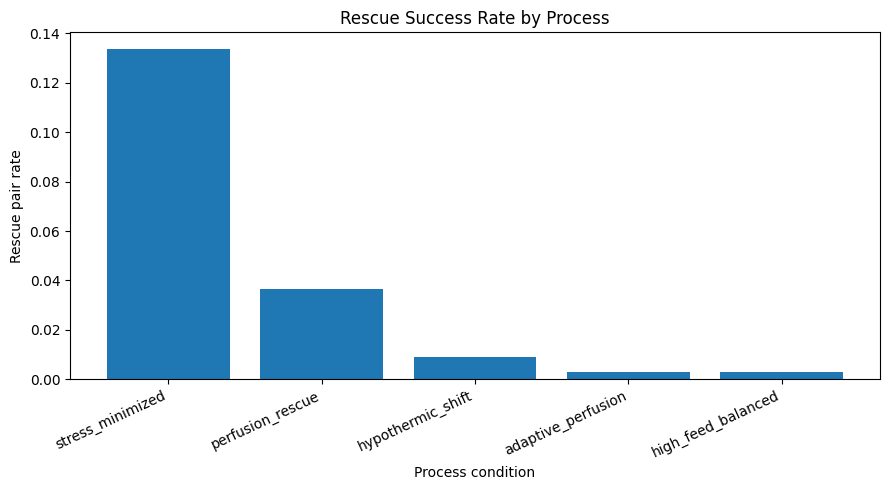

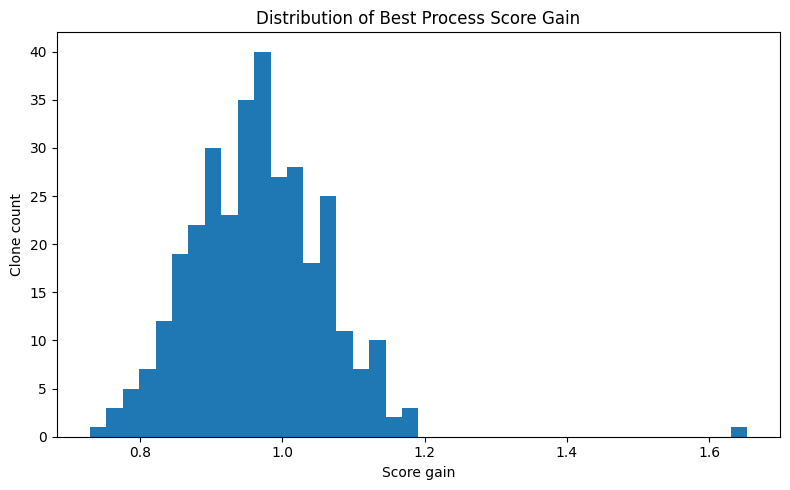

/var/folders/cb/p1vhzxzn6471zz3bzgp_3zph0000gn/T/ipykernel_5553/175957350.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


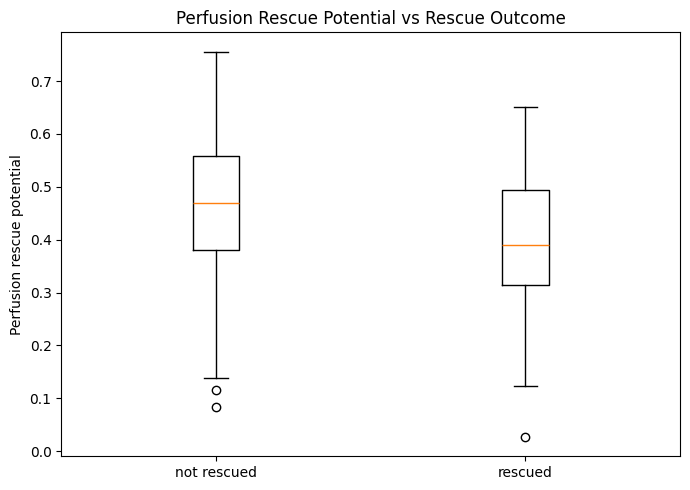

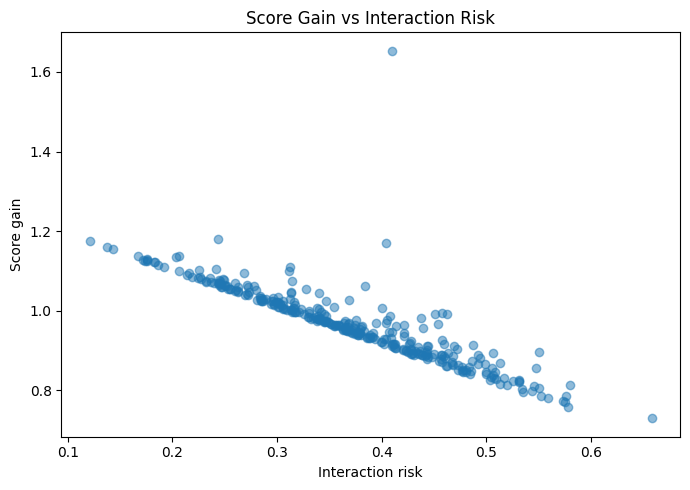

In [11]:
# --------------------------------------------------
# Section 12 — Visualization without seaborn
# --------------------------------------------------

# Plot 1 — rescue success rate by process
plot_df = process_summary.sort_values("rescued_pair_rate", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["process_condition"], plot_df["rescued_pair_rate"])
plt.title("Rescue Success Rate by Process")
plt.xlabel("Process condition")
plt.ylabel("Rescue pair rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# Plot 2 — score gain distribution
plt.figure(figsize=(8, 5))
plt.hist(best_process["score_gain"], bins=40)
plt.title("Distribution of Best Process Score Gain")
plt.xlabel("Score gain")
plt.ylabel("Clone count")
plt.tight_layout()
plt.show()


# Plot 3 — perfusion rescue potential by rescue outcome
rescued_vals = best_process.loc[
    best_process["rescued"], "perfusion_rescue_potential"
].dropna()

non_rescued_vals = best_process.loc[
    ~best_process["rescued"], "perfusion_rescue_potential"
].dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(
    [non_rescued_vals, rescued_vals],
    labels=["not rescued", "rescued"],
)
plt.title("Perfusion Rescue Potential vs Rescue Outcome")
plt.ylabel("Perfusion rescue potential")
plt.tight_layout()
plt.show()


# Plot 4 — score gain vs interaction risk
plt.figure(figsize=(7, 5))
plt.scatter(
    best_process["interaction_risk"],
    best_process["score_gain"],
    alpha=0.5,
)
plt.title("Score Gain vs Interaction Risk")
plt.xlabel("Interaction risk")
plt.ylabel("Score gain")
plt.tight_layout()
plt.show()

## Section 13 — Top Rescue Candidates

This section highlights the most successfully rescued clones.

These clones represent strong examples of:

- process-responsive biology
- recoverable production instability
- adaptive manufacturing potential

Such clones are especially interesting because they may have
been incorrectly discarded during early screening without
process-aware evaluation.

In [12]:
# --------------------------------------------------
# Section 13 — Top rescue candidates
# --------------------------------------------------

top_rescued = (
    rescue_transition_table[rescue_transition_table["rescued"]]
    .sort_values("optimized_score", ascending=False)
    .head(20)
)

print("Top rescued candidates:", top_rescued.shape)
display(top_rescued)

Top rescued candidates: (20, 24)


,clone_id,process_condition,baseline_score,optimized_score,score_gain,baseline_rank,optimized_rank,rescued,interaction_gain,interaction_risk,...,pred_late_agg,optimized_late_agg,pred_rescue_score,pred_rescue_label,perfusion_rescue_potential,stress_adaptation_capacity,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super
0,CLONE_4067,perfusion_rescue,0.875381,2.528754,1.653373,245.0,1.0,True,0.311652,0.409971,...,7.905017,7.196983,0.486387,0,0.395492,0.580428,0.680331,0.512464,0,0
1,CLONE_1973,stress_minimized,1.015624,2.118606,1.102981,217.0,2.0,True,0.072980,0.225036,...,7.526826,5.796870,0.552538,0,0.353058,0.588319,0.444936,0.321481,0,0
2,CLONE_1074,stress_minimized,1.016802,2.081867,1.065065,216.0,3.0,True,0.088098,0.270864,...,8.278448,6.603486,0.586947,1,0.306235,1.000000,0.530779,0.386949,0,0
3,CLONE_4616,stress_minimized,1.035877,2.065103,1.029226,209.0,4.0,True,0.065242,0.312148,...,7.664888,6.039466,0.592751,1,0.451660,0.472099,0.483244,0.445926,0,0
4,CLONE_1420,stress_minimized,0.881196,2.040609,1.159413,243.0,5.0,True,0.067053,0.137682,...,6.519123,4.684341,0.513144,0,0.258786,0.820197,0.131428,0.196688,0,0
5,CLONE_3023,stress_minimized,0.891318,1.975382,1.084064,241.0,6.0,True,0.060225,0.226306,...,6.354022,4.625589,0.478642,0,0.309951,0.598630,0.369556,0.323295,0,0
6,CLONE_2844,stress_minimized,0.854636,1.934883,1.080247,256.0,7.0,True,0.071127,0.248156,...,7.895962,6.193749,0.599261,1,0.225902,0.879457,0.461526,0.354508,0,1
7,CLONE_4614,stress_minimized,1.056877,1.888348,0.831471,204.0,8.0,True,0.066310,0.517002,...,6.968612,5.589015,0.524465,0,0.459853,0.507339,0.517876,0.738574,0,0
8,CLONE_1742,stress_minimized,1.014599,1.880777,0.866178,218.0,9.0,True,0.066008,0.491938,...,7.173989,5.764315,0.566039,0,0.376333,0.557361,0.640979,0.702769,0,0
9,CLONE_4193,stress_minimized,0.987350,1.879302,0.891952,226.0,10.0,True,0.063015,0.443666,...,6.805206,5.337605,0.517387,0,0.163029,0.518576,0.433631,0.633808,0,0


## Section 14 — Save Simulation Outputs

This section exports all simulation outputs for downstream analysis.

Saved outputs include:

- full clone × process simulation table
- rescue transition table
- process-level summary statistics

These files can later be used for:

- visualization
- ranking systems
- reinforcement learning
- adaptive process recommendation models

In [13]:
# --------------------------------------------------
# Section 14 — Save outputs
# --------------------------------------------------

OUTDIR = ROOT / "data" / "synthetic" / "process"
OUTDIR.mkdir(parents=True, exist_ok=True)

simulation_path = OUTDIR / f"notebook07b_process_rescue_simulation_{n_clones}_{scenario}.csv"
transition_path = OUTDIR / f"notebook07b_rescue_transition_table_{n_clones}_{scenario}.csv"
summary_path = OUTDIR / f"notebook07b_rescue_process_summary_{n_clones}_{scenario}.csv"

simulation_df.to_csv(simulation_path, index=False)
rescue_transition_table.to_csv(transition_path, index=False)
process_summary.to_csv(summary_path, index=False)

print("Saved:")
print(simulation_path)
print(transition_path)
print(summary_path)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/process/notebook07b_process_rescue_simulation_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/process/notebook07b_rescue_transition_table_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/process/notebook07b_rescue_process_summary_5000_legacy.csv


##  Biological Interpretation and Strategic Implications

This notebook demonstrates that intrinsic clone quality alone
does not fully determine manufacturability.

Some borderline clones can become production-worthy when
appropriate process conditions are applied.

This supports a more advanced CLD strategy:

1. Remove clearly unstable aggressive clones early
2. Preserve potentially rescuable clones
3. Apply clone-specific process optimization
4. Select final manufacturing candidates after process evaluation

This framework moves CLD from:

"best intrinsic clone wins"

toward:

"best clone × process combination wins"